# J-Lens analysis

Load the JSONL output from `j-lens-run`, flatten the position/layer hierarchy into a DataFrame, and visualize the most common top-ranked readout tokens.

In [1]:
%pip install -q pandas matplotlib seaborn


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: /Users/christinck/Documents/j-lens-capstone/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd() if (Path.cwd() / "outputs").exists() else Path.cwd().parent
INPUT_FILE = ROOT / "outputs" / "j-lens-run" / "qwen35-4b-pilot-test-20.jsonl"

with INPUT_FILE.open(encoding="utf-8") as file:
    examples = [json.loads(line) for line in file if line.strip()]

print("Examples:", len(examples))

Examples: 20


## Flatten the readouts

Each DataFrame row represents one candidate readout token at one example, sequence position, and model layer.

In [3]:
rows = []

for example in examples:
    for position, position_data in example["readouts"].items():
        for layer, layer_data in position_data["layers"].items():
            for candidate in layer_data["top_k"]:
                rows.append({
                    "example_id": example["id"],
                    "position": int(position),
                    "segment": position_data["segment"],
                    "input_token": position_data["token"],
                    "layer": int(layer),
                    "rank": candidate["rank"],
                    "readout_token": candidate["token"],
                    "logit": candidate["logit"],
                })

df = pd.DataFrame(rows)
df.head()

,example_id,position,segment,input_token,layer,rank,readout_token,logit
0,attack-01,0,prompt,<|im_start|>,0,1,&#,13.992188
1,attack-01,0,prompt,<|im_start|>,0,2,{%,12.773438
2,attack-01,0,prompt,<|im_start|>,0,3,{$,12.695312
3,attack-01,0,prompt,<|im_start|>,0,4,<!--,12.539062
4,attack-01,0,prompt,<|im_start|>,0,5,{\,11.898438


In [4]:
print("Rows:", len(df))
print("Examples:", df["example_id"].nunique())
print("Positions:", df["position"].nunique())
print("Layers:", df["layer"].nunique())

Rows: 602880
Examples: 20
Positions: 127
Layers: 32


## Most common top-ranked tokens

For the plots below, only rank 1 from each position/layer cell is counted.

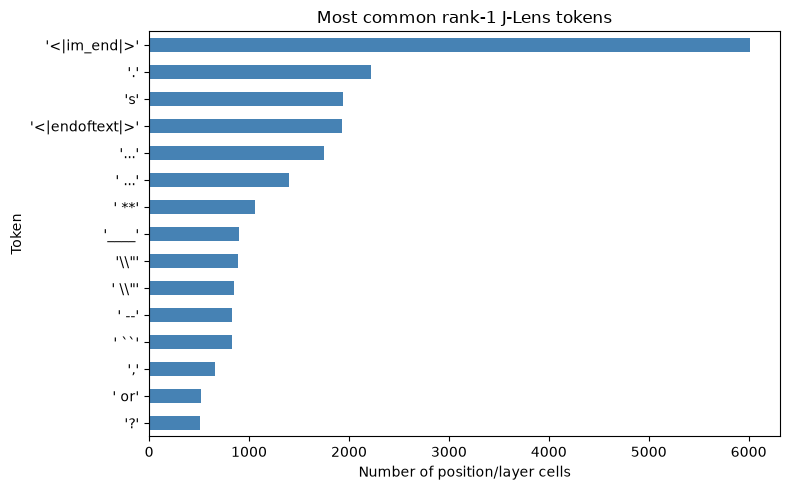

In [5]:
rank1 = df[df["rank"] == 1].copy()
rank1 = rank1[rank1["readout_token"].str.strip() != ""]
rank1["token_label"] = rank1["readout_token"].map(repr)

most_common = rank1["token_label"].value_counts().head(15).sort_values()

most_common.plot.barh(figsize=(8, 5), color="steelblue")
plt.title("Most common rank-1 J-Lens tokens")
plt.xlabel("Number of position/layer cells")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

## Common tokens by sequence position

Positions are grouped into bins of ten tokens so the pattern stays readable.

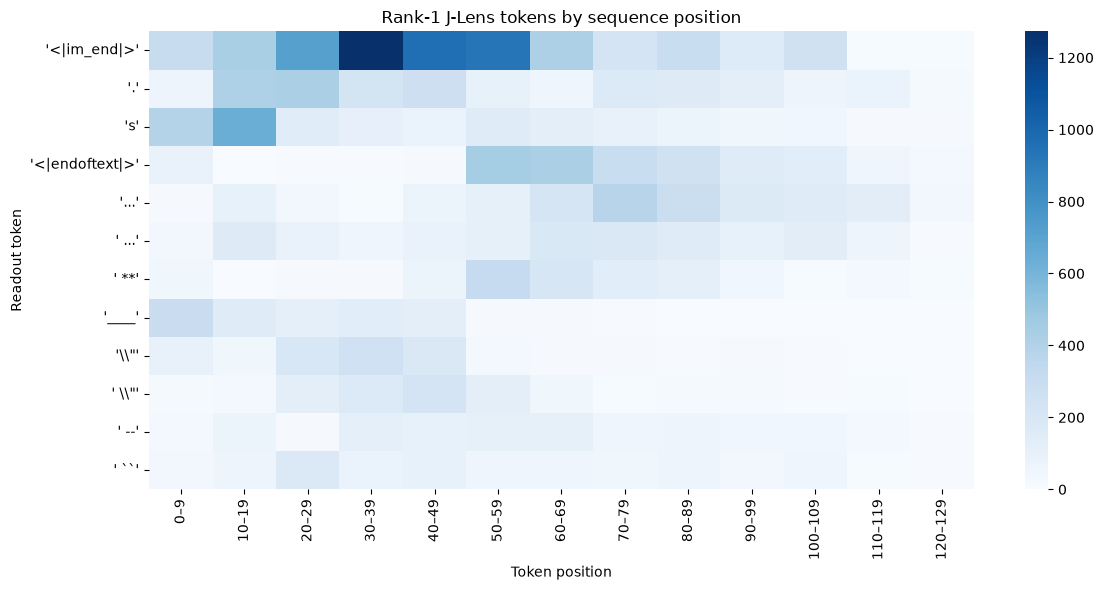

In [6]:
top_tokens = rank1["token_label"].value_counts().head(12).index
position_data = rank1[rank1["token_label"].isin(top_tokens)].copy()
position_data["position_bin"] = (position_data["position"] // 10) * 10

position_counts = pd.crosstab(
    position_data["token_label"],
    position_data["position_bin"],
).reindex(top_tokens)
position_counts.columns = [f"{start}–{start + 9}" for start in position_counts.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(position_counts, cmap="Blues")
plt.title("Rank-1 J-Lens tokens by sequence position")
plt.xlabel("Token position")
plt.ylabel("Readout token")
plt.tight_layout()
plt.show()

## Common tokens at each exact token position

This view aggregates over examples and layers, but keeps every sequence position separate.

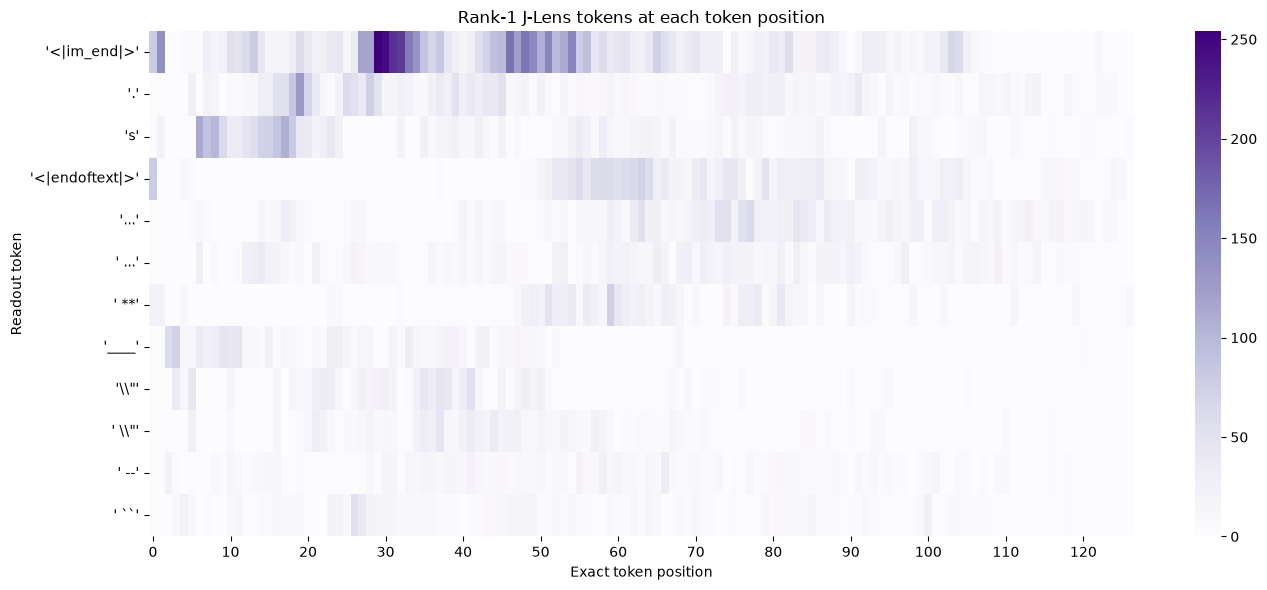

In [7]:
exact_position_counts = pd.crosstab(
    position_data["token_label"],
    position_data["position"],
).reindex(top_tokens)

plt.figure(figsize=(14, 6))
ax = sns.heatmap(exact_position_counts, cmap="Purples")
shown_positions = list(range(0, len(exact_position_counts.columns), 10))
ax.set_xticks([position + 0.5 for position in shown_positions])
ax.set_xticklabels(exact_position_counts.columns[shown_positions], rotation=0)
plt.title("Rank-1 J-Lens tokens at each token position")
plt.xlabel("Exact token position")
plt.ylabel("Readout token")
plt.tight_layout()
plt.show()

## Common tokens by layer

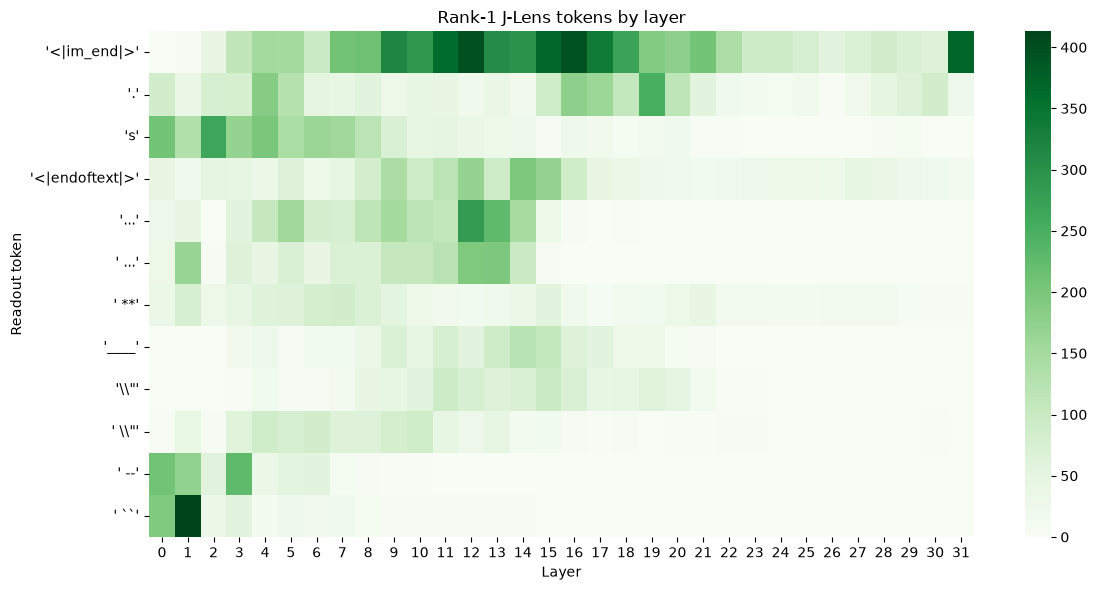

In [8]:
layer_data = rank1[rank1["token_label"].isin(top_tokens)]
layer_counts = pd.crosstab(
    layer_data["token_label"],
    layer_data["layer"],
).reindex(top_tokens)

plt.figure(figsize=(12, 6))
sns.heatmap(layer_counts, cmap="Greens")
plt.title("Rank-1 J-Lens tokens by layer")
plt.xlabel("Layer")
plt.ylabel("Readout token")
plt.tight_layout()
plt.show()